# Análise de resultados do AutoML

Carrega os artefatos `automl_results` e `best_trial` direto do ClearML e gera os gráficos de forma interativa. Rode as células em ordem; a segunda célula é onde você define quais tasks analisar.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from clearml import Task

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 1. Configura quais tasks analisar

Preenche os IDs e (opcionalmente) rótulos legíveis pra cada task.

In [2]:
TASKS = {
    "arch_sweep": "a5e0161756b8437685a589dfb0d40d62",
    "fp_first": "1787e863c03e4b88b57b66f6e136d539",
}

## 2. Carrega os artefatos de cada task

In [3]:
def carregar_task(label: str, task_id: str):
    task = Task.get_task(task_id=task_id)
    artifacts = task.artifacts
    if "automl_results" not in artifacts:
        raise KeyError(f"{label} ({task_id}) não tem artefato 'automl_results'. "
                       f"Disponíveis: {list(artifacts.keys())}")
    df = artifacts["automl_results"].get()
    if not isinstance(df, pd.DataFrame):
        df = pd.read_csv(artifacts["automl_results"].get_local_copy())
    df = df.copy()
    df["_task_label"] = label

    best_trial = artifacts["best_trial"].get() if "best_trial" in artifacts else None
    return df, best_trial

dfs = {}
bests = {}
for label, task_id in TASKS.items():
    df, best = carregar_task(label, task_id)
    dfs[label] = df
    bests[label] = best
    print(f"✓ {label}: {len(df)} trials carregados")

df_all = pd.concat(dfs.values(), ignore_index=True)
df_all.shape

✓ arch_sweep: 3888 trials carregados
✓ fp_first: 1152 trials carregados


(5040, 52)

## 3. Resumo por task

In [4]:
linhas = []
for label, df in dfs.items():
    aprovados = df[df.get("aprovado", True) == True]
    linhas.append({
        "task": label,
        "n_trials": len(df),
        "n_aprovados": len(aprovados),
        "pct_aprovados": round(100 * len(aprovados) / len(df), 1) if len(df) else 0.0,
        "max_eventos_detectados": df["eventos_detectados"].max() if "eventos_detectados" in df else None,
        "min_fp_por_mes": df["fp_por_mes"].min() if "fp_por_mes" in df else None,
    })
resumo = pd.DataFrame(linhas)
resumo

,task,n_trials,n_aprovados,pct_aprovados,max_eventos_detectados,min_fp_por_mes
0,arch_sweep,3888,1062,27.3,7,0.0
1,fp_first,1152,823,71.4,6,0.0


## 4. Melhor trial salvo em cada task (artefato `best_trial`)

In [5]:
for label, best in bests.items():
    print(f"--- {label} ---")
    if best is None:
        print("  (sem artefato best_trial)\n")
        continue
    for chave in ["eventos_detectados", "eventos_total", "lead_medio_h",
                  "fp_por_mes", "aprovado", "vivo"]:
        if chave in best:
            print(f"  {chave}: {best[chave]}")
    if "trial" in best:
        print(f"  trial: {best['trial']}")
    print()

--- arch_sweep ---
  eventos_detectados: 6
  eventos_total: 8
  lead_medio_h: 18.3
  fp_por_mes: 0.94
  aprovado: True
  vivo: False
  trial: {'baseline': {'max_age_days': None, 'min_hours': 100.0, 'window_days': None, 'window_hours': 3000}, 'baseline_hours': 3000, 'baseline_label': '3000h', 'baseline_mode': 'movel', 'confirm': 2, 'ewma': '2h', 'exclude_alarm_h': 1.0, 'exclude_days': 0, 'grid': '2min', 'min_alert': '0min', 'model': 'pca', 'sustain': '30min', 'threshold': 99.9, 'threshold_kind': 'percentil'}

--- fp_first ---
  eventos_detectados: 5
  eventos_total: 8
  lead_medio_h: 8.8
  fp_por_mes: 0.63
  aprovado: True
  vivo: False
  trial: {'baseline': {'max_age_days': None, 'min_hours': 100.0, 'window_days': None, 'window_hours': 3000.0}, 'baseline_hours': 3000.0, 'baseline_label': '3000h', 'baseline_mode': 'movel', 'confirm': 2, 'ewma': '1h', 'exclude_alarm_h': 1.0, 'exclude_days': 0, 'grid': '2min', 'min_alert': '30min', 'model': 'pca', 'sustain': '1h', 'threshold': 99.995, 'th

## 5. Ranking — top configurações (todas as tasks juntas)

Mesmo critério do `select_best()` do `automl.py`: mais detecção → mais detecção na 2ª metade da série → maior antecedência (lead) → menor falso positivo. Só considera trials aprovados (dentro do teto de FP), se houver algum.

In [6]:
TOP_N = 15

def ranking(df: pd.DataFrame, top_n: int = TOP_N) -> pd.DataFrame:
    """Mesmo critério de select_best() do automl_clearml.py: prioriza trials
    aprovado E vivo; se nenhum for vivo, relaxa pra só aprovado; se nenhum
    aprovado, usa todos. Sem isso o top-1 daqui pode não bater com o
    best_trial oficial salvo pela task (que já aplica esse mesmo filtro)."""
    aprovado = df.get("aprovado", pd.Series(True, index=df.index)) == True
    vivo = df.get("vivo", pd.Series(True, index=df.index)) == True
    base = df[aprovado & vivo]
    if base.empty:
        base = df[aprovado]
    if base.empty:
        base = df
    cols = [c for c in ["eventos_detectados", "det_2a_metade", "lead_medio_h", "fp_por_mes"]
            if c in base.columns]
    asc = [False, False, False, True][:len(cols)]
    return base.sort_values(cols, ascending=asc).head(top_n)

rank_geral = ranking(df_all)
cols_mostrar = [c for c in [
    "_task_label", "eventos_detectados", "eventos_total", "lead_medio_h",
    "fp_por_mes", "det_1a_metade", "det_2a_metade",
    "trial.model", "trial.baseline_label", "model", "baseline_label",
] if c in rank_geral.columns]
rank_geral[cols_mostrar]

,_task_label,eventos_detectados,eventos_total,lead_medio_h,fp_por_mes,det_1a_metade,det_2a_metade,trial.model,trial.baseline_label
193,arch_sweep,6,8,18.3,0.94,5,1,pca,3000h
196,arch_sweep,6,8,18.2,0.94,5,1,pca,3000h
147,arch_sweep,5,8,16.4,0.51,4,1,pca,3000h
146,arch_sweep,5,8,16.4,0.60,4,1,pca,3000h
195,arch_sweep,5,8,15.7,0.86,4,1,pca,3000h
194,arch_sweep,5,8,15.7,0.94,4,1,pca,3000h
171,arch_sweep,5,8,9.8,0.60,4,1,pca,3000h
170,arch_sweep,5,8,9.8,0.68,4,1,pca,3000h
3987,fp_first,5,8,8.8,0.63,4,1,pca,3000h
3986,fp_first,5,8,8.8,0.72,4,1,pca,3000h


## 6. Gráfico: Detecção x Falso Positivo (todas as tasks)

Cada ponto é uma configuração testada. Tamanho do ponto = antecedência (lead time).

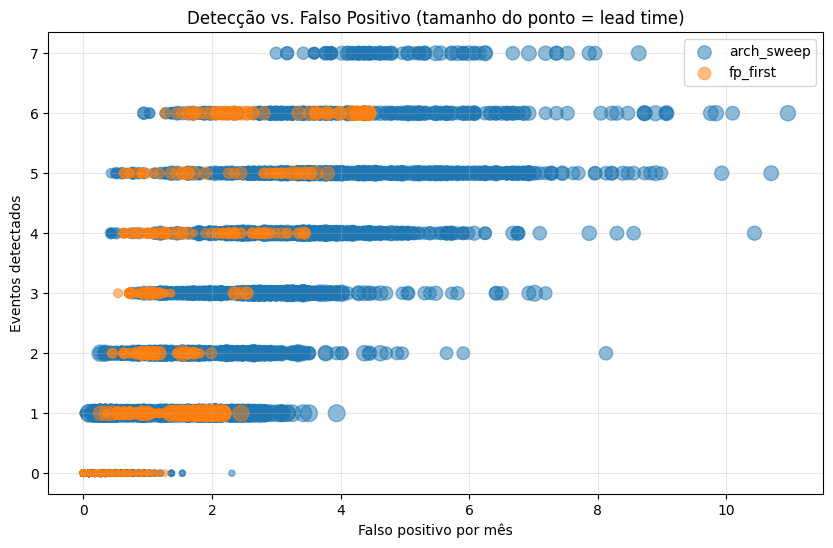

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, grupo in df_all.groupby("_task_label"):
    tamanhos = 20 + grupo["lead_medio_h"].fillna(0).clip(lower=0) * 3 if "lead_medio_h" in grupo else 30
    ax.scatter(grupo["fp_por_mes"], grupo["eventos_detectados"],
               s=tamanhos, alpha=0.5, label=label)

ax.set_xlabel("Falso positivo por mês")
ax.set_ylabel("Eventos detectados")
ax.set_title("Detecção vs. Falso Positivo (tamanho do ponto = lead time)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. Gráfico: Top configurações por task (barra horizontal)

Muda `LABEL_ESCOLHIDO` pra ver o top de outra task.

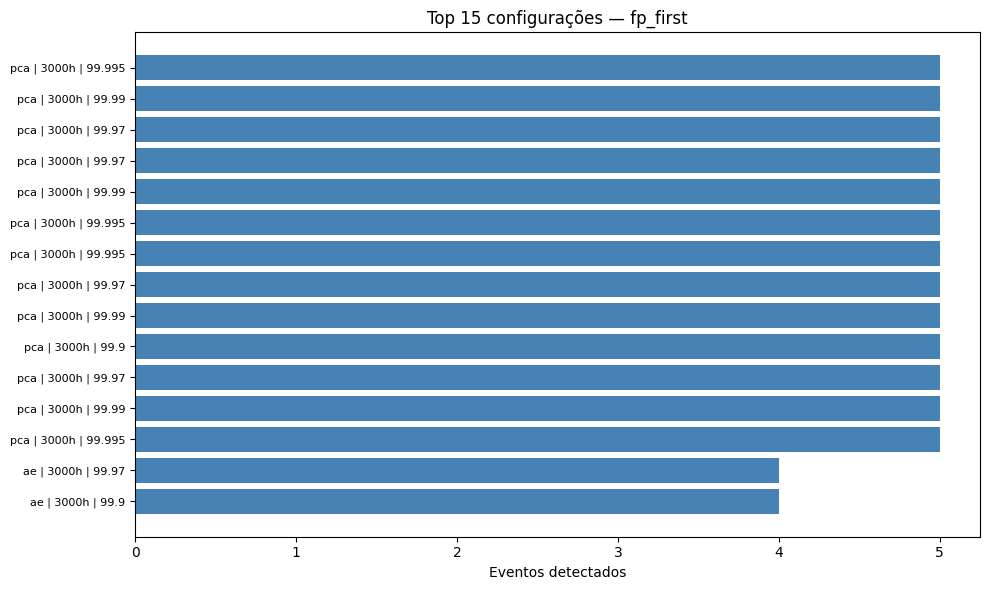

In [8]:
LABEL_ESCOLHIDO = list(dfs.keys())[1]  # troca aqui pelo nome da task que quiser ver

rank_task = ranking(dfs[LABEL_ESCOLHIDO])
cols_label = [c for c in ["trial.model", "trial.baseline_label", "trial.threshold",
               "model", "baseline_label", "threshold"] if c in rank_task.columns]
labels = rank_task[cols_label].astype(str).agg(" | ".join, axis=1) if cols_label else rank_task.index.astype(str)

fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(rank_task))))
ax.barh(range(len(rank_task)), rank_task["eventos_detectados"], color="steelblue")
ax.set_yticks(range(len(rank_task)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Eventos detectados")
ax.set_title(f"Top {len(rank_task)} configurações — {LABEL_ESCOLHIDO}")
plt.tight_layout()
plt.show()

## 8. Gráfico: distribuição de FP por task (boxplot)

Ajuda a ver se uma task, no geral, tende a gerar mais falso positivo que outra — não só o melhor caso.

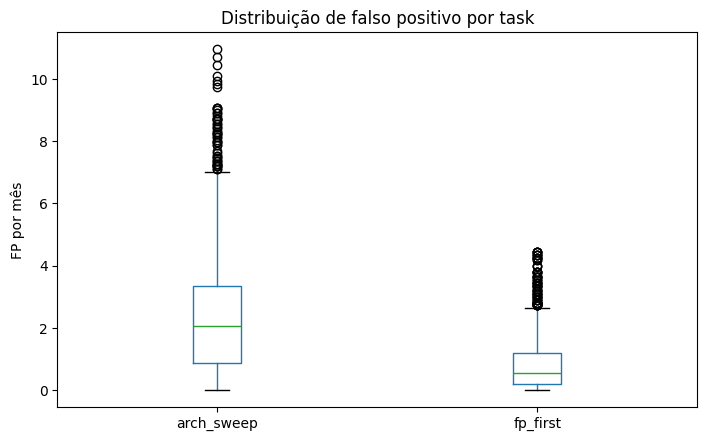

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
df_all.boxplot(column="fp_por_mes", by="_task_label", ax=ax, grid=False)
ax.set_xlabel("")
ax.set_ylabel("FP por mês")
ax.set_title("Distribuição de falso positivo por task")
plt.suptitle("")
plt.show()

## 9. Série temporal com alarmes detectados e falsos positivos

Usa o pipeline real (`DetectionReplay` + `viz`) em vez de reimplementar a lógica de avaliação — mais seguro, já é o código testado que gera os números oficiais.

Escolhe um trial do ranking (de uma task específica), converte pra `CONFIG` no formato que `DetectionReplay.run()` espera, roda o replay e plota.

In [10]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

from cabiunas_pdm import viz
from cabiunas_pdm.replay import DetectionReplay, SENSORS_OVERVIEW

viz.usar_estilo()

In [11]:
def _pega(row: pd.Series, *nomes, default=None):
    """Tenta várias variações de nome de coluna: com prefixo 'trial.' (como o
    pd.json_normalize achata o automl_results) e sem prefixo (best_trial cru)."""
    for nome in nomes:
        if nome in row and pd.notna(row[nome]):
            return row[nome]
    return default


def row_para_config(row: pd.Series) -> dict:
    """Converte uma linha do ranking/automl_results no dict CONFIG que
    DetectionReplay.run(**CONFIG) espera. baseline_hours/baseline_mode já vêm
    prontos no trial_dict salvo pelo automl_clearml.py (evaluate()), não
    precisa reconstruir a BaselinePolicy manualmente."""
    return dict(
        model=_pega(row, "trial.model", "model"),
        grid=_pega(row, "trial.grid", "grid"),
        baseline_hours=_pega(row, "trial.baseline_hours", "baseline_hours"),
        baseline_mode=_pega(row, "trial.baseline_mode", "baseline_mode"),
        exclude_days=int(_pega(row, "trial.exclude_days", "exclude_days")),
        exclude_alarm_h=float(_pega(row, "trial.exclude_alarm_h", "exclude_alarm_h")),
        ewma=_pega(row, "trial.ewma", "ewma"),
        threshold=_pega(row, "trial.threshold", "threshold"),
        sustain=_pega(row, "trial.sustain", "sustain"),
        confirm=int(_pega(row, "trial.confirm", "confirm")),
        min_alert=_pega(row, "trial.min_alert", "min_alert", default="0min"),
    )

In [12]:
# ── escolhe qual trial rodar no replay: pega do ranking (ex: o #1 de uma task) ──
TASK_PARA_INSPECIONAR = list(dfs.keys())[1]   # troca pelo nome da task
linha_trial = ranking(dfs[TASK_PARA_INSPECIONAR], top_n=1).iloc[0]

CONFIG = row_para_config(linha_trial)
print("CONFIG:", CONFIG)

resultado = DetectionReplay(max_fp_per_month=1.0).run(**CONFIG)

CONFIG: {'model': 'pca', 'grid': '2min', 'baseline_hours': np.float64(3000.0), 'baseline_mode': 'movel', 'exclude_days': 0, 'exclude_alarm_h': 1.0, 'ewma': '1h', 'threshold': np.float64(99.995), 'sustain': '1h', 'confirm': 2, 'min_alert': '30min'}
[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30
[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária
[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)
[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline
[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl
[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma1h|q99.995|sust1h|conf2|min30min -> 5/8 eventos | lead 8.8 h | FP 0.43/mês


In [13]:
m = resultado.metrics
horas_alerta = float(resultado.alert.fillna(False).sum()) * 2 / 60   # ajusta o fator se a grade não for 2min

print(f"PLACAR — {TASK_PARA_INSPECIONAR}")
print(f"  falhas antecipadas ......... {m['eventos_detectados']} de {m['eventos_total']}")
print(f"  antecedência média ........ {m['lead_medio_h']} h")
print(f"  falso positivo ............ {m['fp_por_mes']}/mês  (líquido {m['fp_por_mes_liquido']}/mês,"
      f" descontando os que coincidem com alarme ativo)")
print(f"  tempo em alarme falso ..... {m['fp_horas_por_mes']} h/mês")
print(f"  episódios de alarme antecipados ... {m['alarmes_antecipados']} (avaliação secundária)")
print(f"  dias de operação avaliados ........ {m['dias_avaliados']:.0f}")
print()
print(f"  tempo TOTAL em alerta no período: {horas_alerta:.0f} h "
      f"({horas_alerta/24:.1f} dias equivalentes)")

resultado.episodes_table()["tipo"].value_counts().to_frame("episódios")

PLACAR — fp_first
  falhas antecipadas ......... 5 de 8
  antecedência média ........ 8.8 h
  falso positivo ............ 0.43/mês  (líquido 0.34/mês, descontando os que coincidem com alarme ativo)
  tempo em alarme falso ..... 10.1 h/mês
  episódios de alarme antecipados ... 7/132 (avaliação secundária)
  dias de operação avaliados ........ 350

  tempo TOTAL em alerta no período: 347 h (14.5 dias equivalentes)


,episódios
tipo,
detecção,6
falso positivo,5
antes de parada (não contado),3


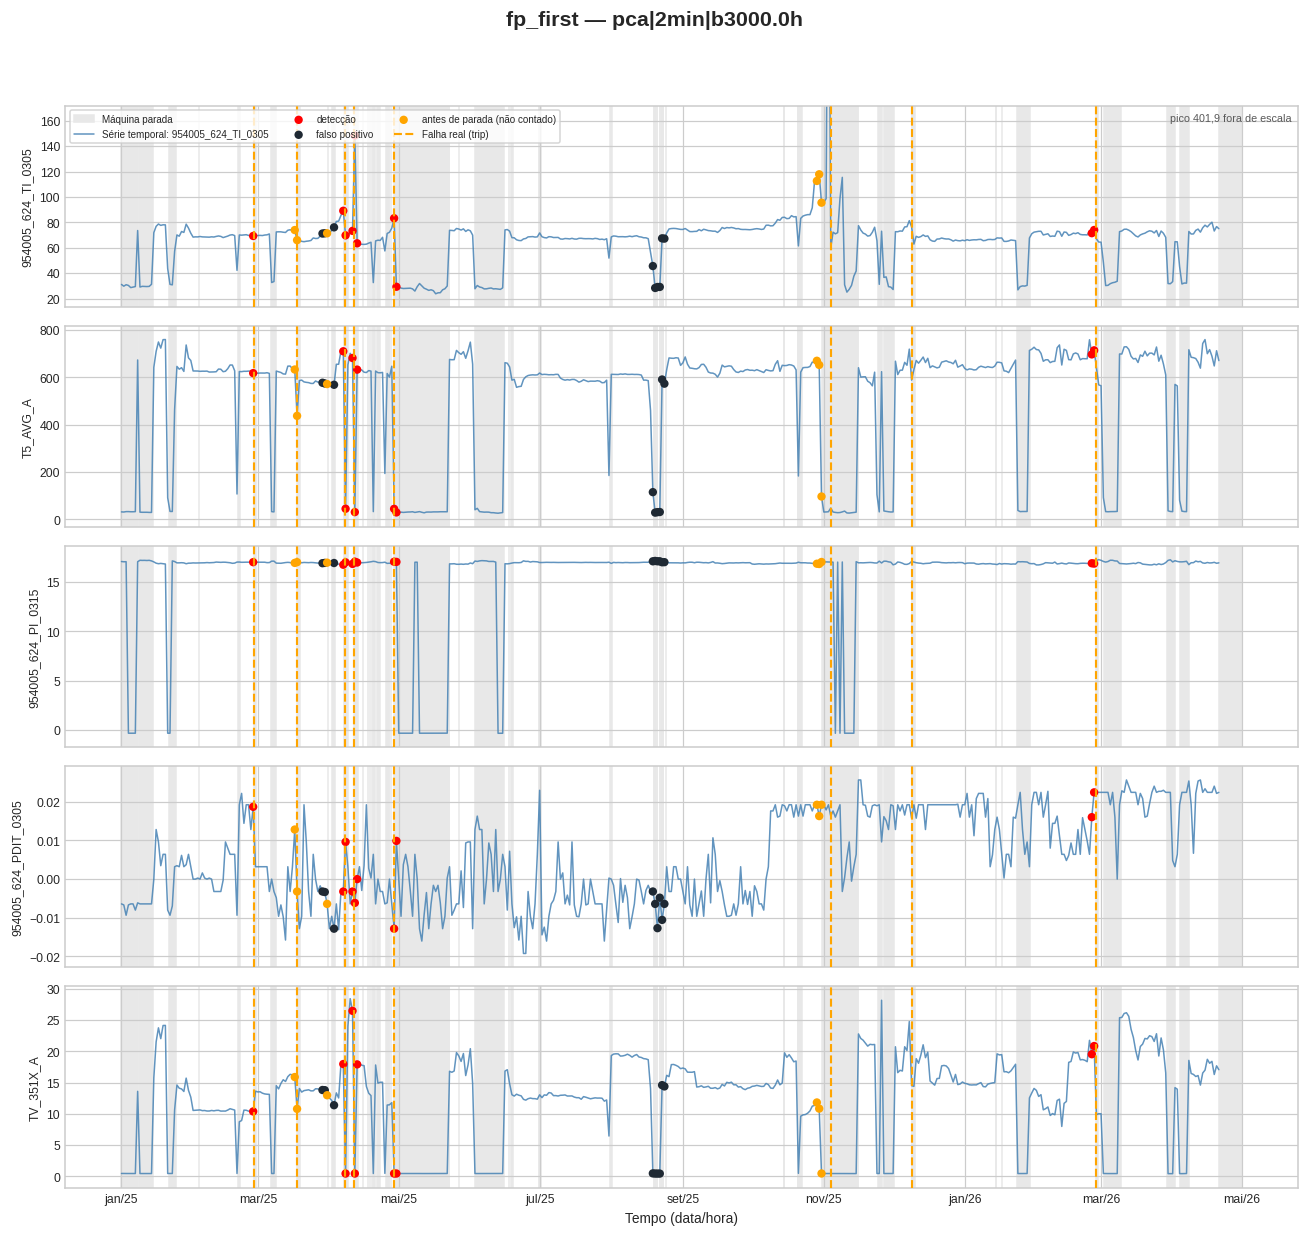

In [14]:
FREQUENCIA = "1D"      # um ponto por dia mantém períodos longos legíveis
sensores = viz.decimar(resultado.sensors[SENSORS_OVERVIEW], FREQUENCIA, "median")
pontos = viz.pontos_por_tipo(resultado, FREQUENCIA)

PREFIXO_TAG = ""  # se as colunas tiverem um prefixo técnico repetido, coloca aqui pra limpar no rótulo

fig, axes = viz.plt.subplots(len(sensores.columns), 1, sharex=True,
                             figsize=(viz.LARGURA, viz.ALTURA_PAINEL * 4.5))
for i, coluna in enumerate(sensores.columns):
    ax = axes[i]
    serie = sensores[coluna]
    viz.sombrear_paradas(ax, resultado.operability, FREQUENCIA, rotulo=(i == 0))
    ax.plot(serie.index, serie.to_numpy(), color=viz.COR_SERIE, linewidth=1.0,
            alpha=0.85, label=f"Série temporal: {coluna.replace(PREFIXO_TAG, '')}")
    for tipo, quando in pontos.items():
        valores = serie.reindex(quando).dropna()
        if valores.empty:
            continue
        ax.scatter(valores.index, valores.to_numpy(), s=30, zorder=4,
                   color=viz.CORES_EPISODIO[tipo], edgecolor="none",
                   label=tipo if i == 0 else None)
    viz.marcar_eventos(ax, resultado.events, rotulo="Falha real (trip)" if i == 0 else None)
    viz._ylim_robusto(ax, serie)
    ax.set_ylabel(coluna.replace(PREFIXO_TAG, ""), fontsize=8)
    if i == 0:
        h, l = ax.get_legend_handles_labels()
        ax.legend(h, l, loc="upper left", fontsize=6.5, ncol=3, frameon=True)

axes[-1].set_xlabel("Tempo (data/hora)")
viz._formatar_eixo_x(axes[-1], sensores.index)
fig.suptitle(f"{TASK_PARA_INSPECIONAR} — {CONFIG['model']}|{CONFIG['grid']}|b{CONFIG['baseline_hours']}h",
             fontsize=14, fontweight="bold", y=0.995)
fig.tight_layout(rect=viz.RECT_TITULO)